# Dumper Truck Detector — Building the Reference Set

This notebook builds a **similarity-based** detector: instead of training a yes/no classifier (which needs both "dumper truck" and "not a dumper truck" example photos to mean anything), it compares each live webcam frame to your known dumper-truck photos using a frozen, pretrained vision model, and reports a match if the frame looks similar enough to enough of them. Nothing is actually trained/fitted here — the pretrained model's weights never change — so there's no risk of it latching onto some accidental shortcut in your photos (like "this came from my webcam") the way a trained classifier can.

**Before running this notebook**, put your dumper truck photos here — just one folder, no "no_dumper_truck" folder needed:

```
model_training/
  image_data/
    dumper_truck/
        img001.jpg
        img002.png
        ...
```

A few tips that matter a lot for this approach, since it works by similarity:

- **More photos help**, but so does **variety among them**. If every photo is the same truck from the same spot in the same lighting, the model has very little to generalize from. Walk around it, get different angles/distances, different times of day if you can, different backgrounds — the more the *truck itself* is the one consistent thing across your photos (rather than the room, the lighting, or the camera), the better it'll generalize to a new live view of it.
- JPEG, PNG, or a mix is fine.
- You don't need to balance anything or worry about "enough" negative examples — there aren't any, by design.

At the end, this notebook saves:
- `saved_model/prototype_embeddings.npy` — a bank of reference embeddings computed from your photos (including some synthetic-fog variants, for robustness in hazy conditions)
- `saved_model/threshold.json` — the similarity threshold and metadata used to decide "match" vs "no match"

...and copies both into `../backend/saved_model/`, where the FastAPI backend expects them. The backend auto-detects these files and switches into similarity mode automatically — no code changes needed there.


In [1]:
import json
import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image, ImageFilter

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.17.0
GPU available: []


## 1. Configuration

In [2]:
DATA_DIR = Path("image_data/dumper_truck")
IMG_SIZE = (224, 224)          # MobileNetV2's native input size

TOP_K = 5                      # a live frame is compared to all reference embeddings;
                                # this many of the closest matches are averaged for the score

FOG_INTENSITIES = [0.25, 0.45] # each photo also gets these two synthetic-fog variants added
                                # to the reference bank, so hazy live frames still find a match

ENHANCE_VISIBILITY = True      # must match the backend's ENHANCE_VISIBILITY setting (default: on) -
                                # both sides need to preprocess frames the same way

SAVED_MODEL_DIR = Path("saved_model")
SAVED_MODEL_DIR.mkdir(exist_ok=True)

BACKEND_SAVED_MODEL_DIR = Path("../backend/saved_model")


## 2. Sanity-check your photos

In [3]:
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Expected folder not found: {DATA_DIR.resolve()}\n"
        "Create it and add your dumper truck photos before continuing."
    )

image_paths = sorted(
    p for p in DATA_DIR.iterdir()
    if p.is_file() and not p.name.startswith(".")
)
print(f"Found {len(image_paths)} photos in {DATA_DIR}")

if len(image_paths) == 0:
    raise ValueError(f"No images found in {DATA_DIR}. Add some photos and re-run this cell.")
if len(image_paths) < 15:
    print(
        "Warning: fewer than 15 photos. This will likely still work but will be less "
        "reliable and less tolerant of different angles/lighting than a larger, more "
        "varied set would be."
    )


Found 100 photos in image_data\dumper_truck


## 3. Visibility enhancement (must match the backend)

The backend applies a CLAHE-based contrast boost to every live frame before classifying it (to help with fog/haze — see the main README). For the similarity comparison to be meaningful, the reference photos need to go through the *same* preprocessing here. If you ever change `ENHANCE_VISIBILITY` or the backend's `.env`, keep both sides in sync.

In [4]:
def enhance_visibility(image: Image.Image) -> Image.Image:
    """Same CLAHE-based contrast enhancement used by the backend (see
    backend/app/model_service.py) — kept in sync manually since this notebook
    and the backend run as separate processes."""
    array = np.array(image.convert("RGB"))
    lab = cv2.cvtColor(array, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l_channel)

    enhanced_lab = cv2.merge((l_enhanced, a_channel, b_channel))
    enhanced_rgb = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)
    return Image.fromarray(enhanced_rgb)


## 4. Synthetic fog variants

For each photo, this also generates a couple of hazier-looking copies and includes their embeddings in the reference bank too — so a live frame in mild-to-moderate fog still has a good chance of matching *something* in the bank, even though none of your source photos were actually shot in fog.

In [5]:
def add_synthetic_fog(image: Image.Image, intensity: float) -> Image.Image:
    array = np.array(image.convert("RGB"), dtype=np.float32)
    haze_color = np.random.uniform(180.0, 255.0, size=(3,)).astype(np.float32)
    hazy = array * (1.0 - intensity) + haze_color * intensity
    hazy = np.clip(hazy, 0, 255).astype(np.uint8)
    return Image.fromarray(hazy).filter(ImageFilter.GaussianBlur(radius=1.0))


## 5. Build the frozen feature extractor

MobileNetV2 pretrained on ImageNet, used purely to turn an image into a vector ("embedding") — nothing is trained or fine-tuned here. `pooling="avg"` gives one flat vector per image instead of a spatial feature map.

In [6]:
feature_extractor = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
    pooling="avg",
)
feature_extractor.trainable = False
print("Embedding dimension:", feature_extractor.output_shape[-1])


Embedding dimension: 1280


## 6. Compute embeddings for every photo (plus fog variants)

In [7]:
def load_and_preprocess(path: Path, fog_intensity: float | None = None) -> np.ndarray:
    image = Image.open(path).convert("RGB")
    if ENHANCE_VISIBILITY:
        image = enhance_visibility(image)
    if fog_intensity is not None:
        image = add_synthetic_fog(image, fog_intensity)
    image = image.resize(IMG_SIZE)
    array = np.array(image, dtype=np.float32)
    return tf.keras.applications.mobilenet_v2.preprocess_input(array)


# (path, fog_intensity) for the original + each fog variant of every photo
variants = [(p, None) for p in image_paths]
for p in image_paths:
    for intensity in FOG_INTENSITIES:
        variants.append((p, intensity))

print(
    f"Computing embeddings for {len(variants)} image variants "
    f"({len(image_paths)} originals x {1 + len(FOG_INTENSITIES)})..."
)

batch = np.stack([load_and_preprocess(p, fog) for p, fog in variants])
raw_embeddings = feature_extractor.predict(batch, batch_size=16, verbose=1)

norms = np.linalg.norm(raw_embeddings, axis=1, keepdims=True)
embeddings = raw_embeddings / np.clip(norms, 1e-8, None)  # L2-normalize -> dot product = cosine similarity

print("Embeddings shape:", embeddings.shape)


Computing embeddings for 300 image variants (100 originals x 3)...
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step
Embeddings shape: (300, 1280)


## 7. Pick a similarity threshold from your own photos

For every *original* photo (fog variants excluded here), this checks how similar it is to the rest of your original photos (leave-one-out) — that gives a realistic sense of "how similar does a genuine photo of this truck typically look to the rest of the set." The threshold is set a bit below the low end of that range, so real matches clear it comfortably while unrelated scenes generally won't.

If detection ends up too strict (misses the real truck) or too loose (fires on everything), you don't need to re-run this whole notebook — just edit `threshold.json` directly, or set `SIMILARITY_THRESHOLD` in `backend/.env` to override it without retraining. See the main README.

Leave-one-out top-5 similarity among your own photos:
  min=0.675  median=0.797  max=0.877
Chosen similarity threshold: 0.654


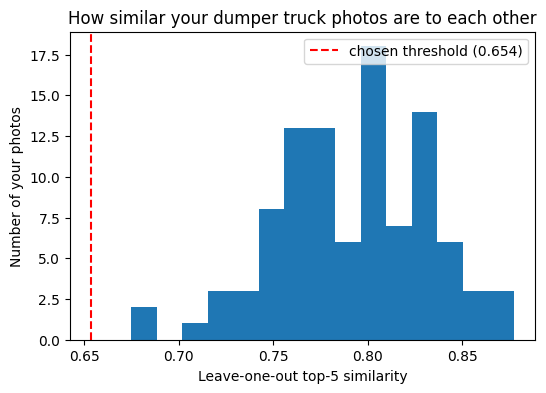

In [46]:
original_mask = np.array([fog is None for _, fog in variants])
original_embeddings = embeddings[original_mask]

sims_matrix = original_embeddings @ original_embeddings.T
np.fill_diagonal(sims_matrix, -1.0)  # exclude comparing a photo to itself

k = min(TOP_K, sims_matrix.shape[0] - 1)
leave_one_out_scores = np.sort(sims_matrix, axis=1)[:, -k:].mean(axis=1)

print(f"Leave-one-out top-{k} similarity among your own photos:")
print(
    f"  min={leave_one_out_scores.min():.3f}  "
    f"median={np.median(leave_one_out_scores):.3f}  "
    f"max={leave_one_out_scores.max():.3f}"
)

THRESHOLD_MARGIN = 0.1
threshold = float(np.percentile(leave_one_out_scores, 15) - THRESHOLD_MARGIN)
threshold = max(0.5, min(threshold, 0.9))  # keep it in a sane range regardless of dataset quirks
print(f"Chosen similarity threshold: {threshold:.3f}")

plt.figure(figsize=(6, 4))
plt.hist(leave_one_out_scores, bins=15)
plt.axvline(threshold, color="red", linestyle="--", label=f"chosen threshold ({threshold:.3f})")
plt.xlabel(f"Leave-one-out top-{k} similarity")
plt.ylabel("Number of your photos")
plt.title("How similar your dumper truck photos are to each other")
plt.legend()
plt.show()


## 8. Save the reference bank

In [47]:
np.save(SAVED_MODEL_DIR / "prototype_embeddings.npy", embeddings.astype(np.float32))

threshold_data = {
    "threshold": threshold,
    "top_k": k,
    "embedding_count": int(embeddings.shape[0]),
    "source_image_count": int(len(image_paths)),
    "img_size": list(IMG_SIZE),
}
with open(SAVED_MODEL_DIR / "threshold.json", "w") as f:
    json.dump(threshold_data, f, indent=2)

print("Saved to:", SAVED_MODEL_DIR.resolve())
print(threshold_data)


Saved to: C:\Users\choud\OneDrive\Desktop\Final\dumper-truck-detector\model_training\saved_model
{'threshold': 0.6537763327360153, 'top_k': 5, 'embedding_count': 300, 'source_image_count': 100, 'img_size': [224, 224]}


## 9. Copy into the backend

In [48]:
BACKEND_SAVED_MODEL_DIR.mkdir(parents=True, exist_ok=True)

for filename in ["prototype_embeddings.npy", "threshold.json"]:
    shutil.copy(SAVED_MODEL_DIR / filename, BACKEND_SAVED_MODEL_DIR / filename)

print("Copied to:", BACKEND_SAVED_MODEL_DIR.resolve())
print("Restart (or start) the FastAPI backend to pick it up.")
print(
    "Note: the backend also needs MobileNetV2's ImageNet weights, which Keras "
    "downloads automatically the first time it runs (needs internet once; "
    "cached locally afterward)."
)


Copied to: C:\Users\choud\OneDrive\Desktop\Final\dumper-truck-detector\backend\saved_model
Restart (or start) the FastAPI backend to pick it up.
Note: the backend also needs MobileNetV2's ImageNet weights, which Keras downloads automatically the first time it runs (needs internet once; cached locally afterward).


## 10. Quick manual test (optional)

Run a photo you did *not* train on through the same pipeline to sanity-check the threshold before wiring up the live webcam.

In [53]:
def check_image(image_path: str):
    array = load_and_preprocess(Path(image_path))
    embedding = feature_extractor.predict(array[None, ...], verbose=0)[0]
    embedding = embedding / (np.linalg.norm(embedding) + 1e-8)

    similarities = embeddings @ embedding
    score = float(np.sort(similarities)[-k:].mean())
    detected = score >= threshold

    verdict = "DUMPER TRUCK DETECTED" if detected else "not detected"
    print(f"Similarity score: {score:.3f}  ->  {verdict}  (threshold={threshold:.3f})")

# Example usage - replace with a real path to try it:
check_image("image_data/dumper_truck/test1.jpg")


Similarity score: 0.600  ->  not detected  (threshold=0.654)


## Later: adding more photos, or switching to a proper classifier

To improve results, just add more (varied!) photos to `image_data/dumper_truck/` and re-run this whole notebook — fully additive, nothing to rebalance.

If you ever collect solid "definitely not a dumper truck" photos taken **the same way** as your positive photos (same webcam, similar range of backgrounds/lighting — not downloaded from elsewhere), a trained binary classifier can outperform this similarity approach, since it can learn the actual visual distinction rather than relying on nearest-neighbor matching. The backend already supports that mode too (it auto-detects `dumper_truck_model.keras` + `class_names.json` if present) — ask for that training notebook variant if/when you have matched negative examples to use with it.
